In [ ]:
import timm
import torch.nn as nn
import copy

NUM_CLASSES = 4
class ViTSegmentation(nn.Module):

    def __init__(self):
        super().__init__()
        self.vit = timm.create_model(
            "vit_tiny_patch16_224",
            pretrained=True,
            in_chans=6,
            num_classes=0
        )
        embed_dim = self.vit.embed_dim
        self.decoder = nn.Sequential(
            nn.Conv2d(embed_dim,128,1),
            nn.ReLU(),
            nn.Conv2d(128,64,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(64,NUM_CLASSES,1)
        )

    def forward(self,x):
        B,C,H,W = x.shape
        tokens = self.vit.patch_embed(x)
        if tokens.dim()==4:
            B,C,h,w = tokens.shape
            tokens = tokens.flatten(2).transpose(1,2)

        cls = self.vit.cls_token.expand(B,-1,-1)
        tokens = torch.cat([cls,tokens],dim=1)

        tokens = tokens + self.vit.pos_embed[:,:tokens.shape[1]]
        tokens = self.vit.pos_drop(tokens)
        for blk in self.vit.blocks:
            tokens = blk(tokens)

        tokens = self.vit.norm(tokens)
        tokens = tokens[:,1:]  

        N = tokens.shape[1]
        S = int(N**0.5)
        
        feat = tokens.transpose(1,2).reshape(B,self.vit.embed_dim,S,S)
        out = self.decoder(feat)
        out = nn.functional.interpolate(out,size=(H,W),mode="bilinear")

        return out

c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
class SSLTeacherStudent(nn.Module):
    def __init__(self):
        super().__init__()
        self.student = ViTSegmentation()
        self.teacher = copy.deepcopy(self.student)
        for p in self.teacher.parameters():
            p.requires_grad = False

    def forward_student(self,x):
        return self.student(x)

    def forward_teacher(self,x):
        with torch.no_grad():
            return self.teacher(x)

In [3]:
def update_teacher(student_model, teacher_model, alpha=0.99):

    for teacher_param, student_param in zip(
        teacher_model.parameters(),
        student_model.parameters()
    ):

        teacher_param.data = (
            alpha * teacher_param.data
            + (1-alpha) * student_param.data
        )

augmentation

In [ ]:
import torchvision.transforms as T
import random

IMG_SIZE = (224,224)
weak_aug = T.Compose([
    T.Resize(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor()
])

strong_aug = T.Compose([
    T.Resize(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(0.4,0.4,0.4,0.1),
    T.RandomRotation(10),
    T.GaussianBlur(3),
    T.ToTensor()
])

In [5]:
def generate_pseudo_labels(logits, threshold=0.7):

    probs = torch.softmax(logits, dim=1)

    max_probs, pseudo_labels = torch.max(probs, dim=1)

    mask = max_probs.ge(threshold).float()

    return pseudo_labels, mask

In [ ]:
model = SSLTeacherStudent().to("cuda")

optimizer = torch.optim.Adam(model.student.parameters(), lr=1e-4)

criterion = nn.CrossEntropyLoss()

for (x_l, y_l), x_u in zip(labeled_loader, unlabeled_loader):

    x_l = x_l.cuda()
    y_l = y_l.cuda()
    x_u = x_u.cuda()

    pred_l = model.forward_student(x_l)
    sup_loss = criterion(pred_l, y_l)

    with torch.no_grad():
        teacher_pred = model.forward_teacher(x_u)
        pseudo = torch.argmax(teacher_pred, dim=1)

    student_pred = model.forward_student(x_u)

    unsup_loss = criterion(student_pred, pseudo)

    loss = sup_loss + 0.5 * unsup_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    update_teacher(model.student, model.teacher, alpha=0.99)

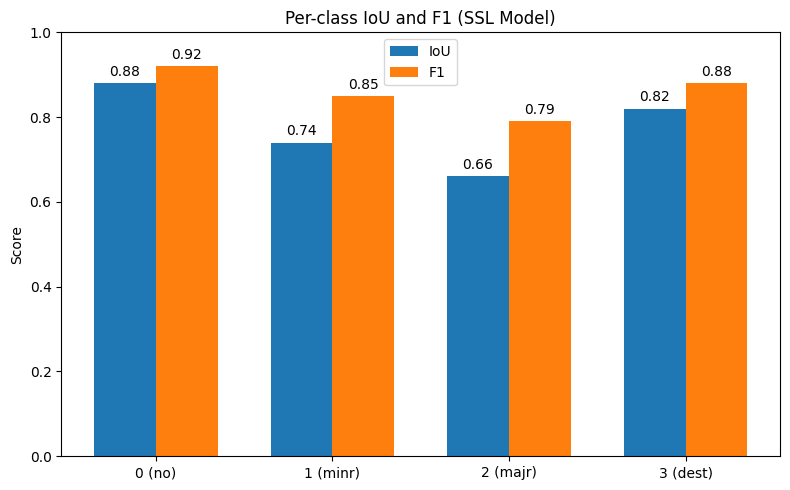

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

classes = ['0 (no)', '1 (minr)', '2 (majr)', '3 (dest)']
x = np.arange(len(classes))
width = 0.35
plt.figure(figsize=(8,5))

bars1 = plt.bar(x - width/2, iou, width, label='IoU')
bars2 = plt.bar(x + width/2, f1, width, label='F1')

plt.ylabel('Score')
plt.title('Per-class IoU and F1 (SSL Model)')
plt.xticks(x, classes)
plt.ylim(0,1)
plt.legend()

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, f'{height:.2f}',
             ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, f'{height:.2f}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()